In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

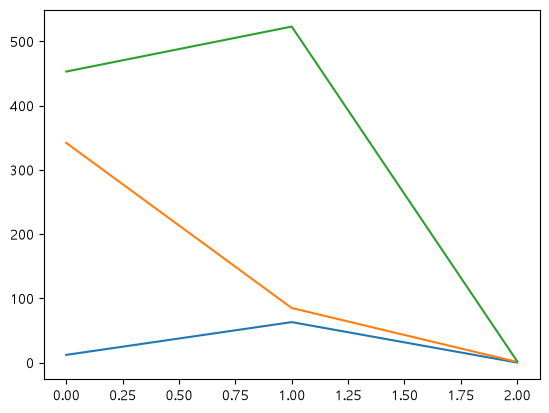

In [11]:
arr = np.array([
        [12,342,453],
        [63,85,523],
        [0,1,2]
    ])

plt.plot(arr)


In [12]:
plt.show()

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "지점": [
        "강남", "강남", "강남", "홍대", "홍대",
        "홍대", "종로", "종로", "종로", "종로"
    ],
    "메뉴": [
        "아메리카노", "라떼", "케이크",
        "아메리카노", "라떼", "케이크",
        "아메리카노", "라떼", "케이크", "아메리카노"
    ],
    "가격": [
        4500, 5500, 7000,
        4500, 5500, 7000,
        4500, 5500, 7000, 4500
    ],
    "판매량": [
        120, 80, 30,
        150, 60, 45,
        90, 100, 25, 110
    ],
    "평점": [
        4.5, 4.2, 4.8,
        4.7, 3.9, 4.6,
        4.1, np.nan, 4.9, 4.3
    ]
}

df = pd.DataFrame(data)
# df의 행/열 개수, 컬럼 이름, 각 컬럼의 자료형을 확인하세요.

# 처음 5개의 데이터만 출력하세요.

# "메뉴" 컬럼만 Series 형태로 가져오고, 실제로 Series 타입인지 확인하세요.

# "지점", "메뉴", "판매량" 세 컬럼만 가져오세요.

# 판매량이 100 이상인 데이터만 추출하세요.

# 판매량이 100 이상이면서 메뉴가 아메리카노인 데이터만 추출하세요.

# "매출"이라는 새로운 컬럼을 만드세요.

# 매출이 가장 높은 행을 찾아서 지점, 메뉴, 매출을 출력하세요. 지금 배운 max()나 argmax()/idxmax() 등을 생각해보세요.

# groupby()를 이용해서 지점별 총 매출을 구하세요.

# groupby()를 이용해서 메뉴별 평균 판매량을 구하세요.

# 지점별로 데이터가 몇 개씩 있는지 구하세요.

# "평점"에 결측값(NaN)이 몇 개 있는지 확인하세요.

# apply()와 함수를 이용해서 "평가"라는 파생변수를 만드세요.
# 전체 판매량의 평균, 편차, 편차의 제곱, 분산, 표준편차를 직접 구해보세요. 처음부터 std()를 쓰지 말고 지금 배운 방식으로 계산합니다.
# 마지막으로 그래프를 3개 그려보세요. 지점별 총 매출은 막대그래프, 판매량은 히스토그램, 가격과 판매량의 관계는 산점도로 표현하세요.

In [38]:
# df의 행/열 개수, 컬럼 이름, 각 컬럼의 자료형을 확인하세요.

print(df.shape)
print(list(df.columns))

for i in df.columns:
    print(f"{i} 컬럼의 타입 : {df[i].dtype}")



df.dtypes

(10, 5)
['지점', '메뉴', '가격', '판매량', '평점']
지점 컬럼의 타입 : str
메뉴 컬럼의 타입 : str
가격 컬럼의 타입 : int64
판매량 컬럼의 타입 : int64
평점 컬럼의 타입 : float64


지점         str
메뉴         str
가격       int64
판매량      int64
평점     float64
dtype: object

In [39]:
# 처음 5개의 데이터만 출력하세요.

df.head()

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
1,강남,라떼,5500,80,4.2
2,강남,케이크,7000,30,4.8
3,홍대,아메리카노,4500,150,4.7
4,홍대,라떼,5500,60,3.9


In [41]:
# "메뉴" 컬럼만 Series 형태로 가져오고, 실제로 Series 타입인지 확인하세요.

type(df["메뉴"])

pandas.Series

In [42]:
# "지점", "메뉴", "판매량" 세 컬럼만 가져오세요.
df[["지점","메뉴","판매량"]]

,지점,메뉴,판매량
0,강남,아메리카노,120
1,강남,라떼,80
2,강남,케이크,30
3,홍대,아메리카노,150
4,홍대,라떼,60
5,홍대,케이크,45
6,종로,아메리카노,90
7,종로,라떼,100
8,종로,케이크,25
9,종로,아메리카노,110


In [47]:
# 판매량이 100 이상인 데이터만 추출하세요.

panmae_mask = df["판매량"] >= 100
df[panmae_mask]

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
3,홍대,아메리카노,4500,150,4.7
7,종로,라떼,5500,100,NaN
9,종로,아메리카노,4500,110,4.3


In [50]:
# 판매량이 100 이상이면서 메뉴가 아메리카노인 데이터만 추출하세요.

sold_ame_mask = (df["판매량"] >= 100) & (df["메뉴"] == "아메리카노")
df[sold_ame_mask]

,지점,메뉴,가격,판매량,평점
0,강남,아메리카노,4500,120,4.5
3,홍대,아메리카노,4500,150,4.7
9,종로,아메리카노,4500,110,4.3


In [53]:
# "매출"이라는 새로운 컬럼을 만드세요.

df["매출"] = df["가격"] * df["판매량"]
df

,지점,메뉴,가격,판매량,평점,매출
0,강남,아메리카노,4500,120,4.5,540000
1,강남,라떼,5500,80,4.2,440000
2,강남,케이크,7000,30,4.8,210000
3,홍대,아메리카노,4500,150,4.7,675000
4,홍대,라떼,5500,60,3.9,330000
5,홍대,케이크,7000,45,4.6,315000
6,종로,아메리카노,4500,90,4.1,405000
7,종로,라떼,5500,100,NaN,550000
8,종로,케이크,7000,25,4.9,175000
9,종로,아메리카노,4500,110,4.3,495000


In [68]:
# 매출이 가장 높은 행을 찾아서 지점, 메뉴, 매출을 출력하세요. 지금 배운 max()나 argmax()/idxmax() 등을 생각해보세요.
df.iloc[df["매출"].argmax()]

지점         홍대
메뉴      아메리카노
가격       4500
판매량       150
평점        4.7
매출     675000
Name: 3, dtype: object

In [70]:
amtn_mask = df["매출"] == max(df["매출"])

df[amtn_mask]

,지점,메뉴,가격,판매량,평점,매출
3,홍대,아메리카노,4500,150,4.7,675000


In [82]:
# groupby()를 이용해서 지점별 총 매출을 구하세요.
df.groupby("지점")["매출"].sum()

지점
강남    1190000
종로    1625000
홍대    1320000
Name: 매출, dtype: int64

In [85]:
# groupby()를 이용해서 메뉴별 평균 판매량을 구하세요.
round(df.groupby("메뉴")[["판매량"]].mean(),2)

,판매량
메뉴,
라떼,80.00
아메리카노,117.50
케이크,33.33


In [103]:
# 지점별로 데이터가 몇 개씩 있는지 구하세요.
# df.groupby("지점")["지점"].count()

df.groupby("지점").size()

지점
강남    3
종로    4
홍대    3
dtype: int64

In [123]:
# "평점"에 결측값(NaN)이 몇 개 있는지 확인하세요.
print(len(df[df["평점"].isna()]))

1


In [124]:
# apply()와 함수를 이용해서 "평가"라는 파생변수를 만드세요.
# 평점이 NaN → "평가 없음"
# 평점 >= 4.5 → "우수"
# 나머지 → "보통"

def is_peong(peong):
    if not peong == peong:
        return "평가 없음"
    return "우수" if peong >= 4.5 else "보통"


df["평가"] = df["평점"].apply(is_peong)

df

,지점,메뉴,가격,판매량,평점,매출,평가
0,강남,아메리카노,4500,120,4.5,540000,우수
1,강남,라떼,5500,80,4.2,440000,보통
2,강남,케이크,7000,30,4.8,210000,우수
3,홍대,아메리카노,4500,150,4.7,675000,우수
4,홍대,라떼,5500,60,3.9,330000,보통
5,홍대,케이크,7000,45,4.6,315000,우수
6,종로,아메리카노,4500,90,4.1,405000,보통
7,종로,라떼,5500,100,NaN,550000,평가 없음
8,종로,케이크,7000,25,4.9,175000,우수
9,종로,아메리카노,4500,110,4.3,495000,보통


In [138]:
# 전체 판매량의 평균, 편차, 편차의 제곱, 분산, 표준편차를 직접 구해보세요. 처음부터 std()를 쓰지 말고 지금 배운 방식으로 계산합니다.

import math

print(df["판매량"].mean())

print(df["판매량"] - df["판매량"].mean())

print((df["판매량"] - df["판매량"].mean())**2)

print(((df["판매량"] - df["판매량"].mean())**2).mean())

print(((df["판매량"] - df["판매량"].mean())**2).mean()**0.5)
print(np.sqrt(((df["판매량"] - df["판매량"].mean())**2).mean()))

81.0
0    39.0
1    -1.0
2   -51.0
3    69.0
4   -21.0
5   -36.0
6     9.0
7    19.0
8   -56.0
9    29.0
Name: 판매량, dtype: float64
0    1521.0
1       1.0
2    2601.0
3    4761.0
4     441.0
5    1296.0
6      81.0
7     361.0
8    3136.0
9     841.0
Name: 판매량, dtype: float64
1504.0
38.781438859330635
38.781438859330635


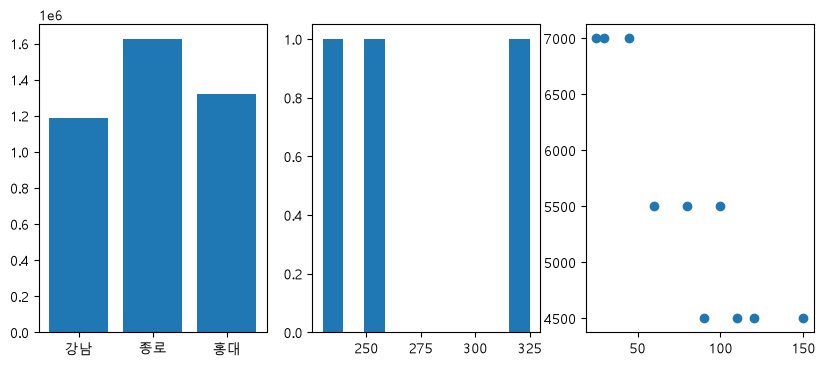

In [176]:
# 마지막으로 그래프를 3개 그려보세요. 지점별 총 매출은 막대그래프, 판매량은 히스토그램, 가격과 판매량의 관계는 산점도로 표현하세요.

fig = plt.figure(figsize=(10,4))

ax1 = fig.add_subplot(1,3,1)
ax2 = fig.add_subplot(1,3,2)
ax3 = fig.add_subplot(1,3,3)

ax1.bar(df.groupby("지점").size().index,df.groupby("지점")["매출"].sum())
ax2.hist(df.groupby("지점")["판매량"].sum())
ax3.scatter(df["판매량"],df["가격"])

In [157]:
df.groupby("지점").size().index

Index(['강남', '종로', '홍대'], dtype='str', name='지점')

In [159]:
df.groupby("지점")["매출"].sum()

지점
강남    1190000
종로    1625000
홍대    1320000
Name: 매출, dtype: int64

In [161]:
df.groupby("메뉴")[["판매량"]].sum()

,판매량
메뉴,
라떼,240
아메리카노,470
케이크,100


In [166]:
ax2.hist(df.groupby("메뉴")["판매량"].sum())

(array([1., 0., 0., 1., 0., 0., 0., 0., 0., 1.]),
 array([100., 137., 174., 211., 248., 285., 322., 359., 396., 433., 470.]),
 <BarContainer object of 10 artists>)

In [172]:
df.groupby("지점")["판매량"].sum()

지점
강남    230
종로    325
홍대    255
Name: 판매량, dtype: int64

In [187]:
# 각 지점에서 매출이 가장 높은 메뉴를 하나씩 찾아 출력하세요.
# 원하는 결과의 형태는 대략:
# 강남    ???
# 홍대    ???
# 종로    ???


df.groupby("메뉴")["매출"].sum()

'아메리카노'

In [194]:
df.groupby("지점")["메뉴"].idxmax("매출")

지점
강남    2
종로    8
홍대    5
Name: 메뉴, dtype: int64

In [31]:
base_path = r"C:\kdt_0900_osh\data_analysis\resource\dataset"
file_name = r"hr_employee_attrition.csv"

file_path = os.path.join(base_path, file_name)

hr_df = pd.read_csv(file_path)
hr_df

,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


In [39]:
hr_df.info()
hr_df.duplicated(subset=["Attrition","Education"]).sum()


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Attrition                1470 non-null   str  
 1   Age                      1470 non-null   int64
 2   Gender                   1470 non-null   str  
 3   MaritalStatus            1470 non-null   str  
 4   Education                1470 non-null   int64
 5   Department               1470 non-null   str  
 6   JobRole                  1470 non-null   str  
 7   BusinessTravel           1470 non-null   str  
 8   OverTime                 1470 non-null   str  
 9   DistanceFromHome         1470 non-null   int64
 10  MonthlyIncome            1470 non-null   int64
 11  PercentSalaryHike        1470 non-null   int64
 12  StockOptionLevel         1470 non-null   int64
 13  TotalWorkingYears        1470 non-null   int64
 14  YearsAtCompany           1470 non-null   int64
 15  EnvironmentSati

np.int64(1460)

#### 야근(OverTime)을 하는 직원과 야근을 하지 않는 직원의 이직률 차이가 얼마나 나는지 비교하고 결과를 서술하세요.

In [27]:
overtime_attrition = pd.crosstab(hr_df["OverTime"], hr_df["Attrition"],normalize="index") * 100

Text(0, 0.5, '비율(%)')

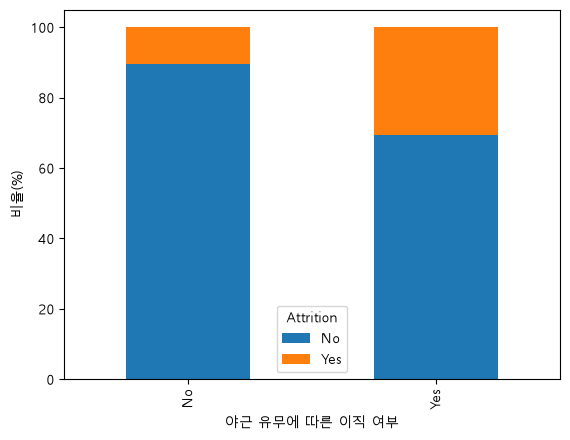

In [43]:
overtime_attrition.plot(kind="bar",stacked=True)
plt.xlabel("야근 유무에 따른 이직 여부")
plt.ylabel("비율(%)")

#### 이직한 직원(Attrition = Yes)과 잔류한 직원(No)의 월소득(MonthlyIncome) 평균 및 분포 차이 비교(boxplot 추천)

In [37]:
attrition_income = hr_df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


Text(0, 0.5, '월급')

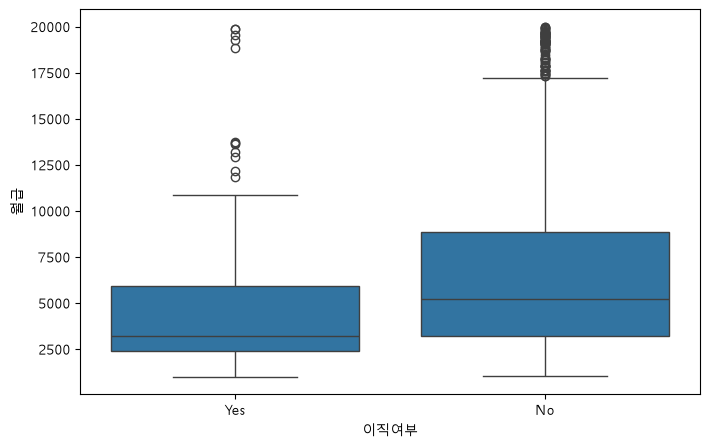

In [52]:
plt.figure(figsize=(8,5))
sns.boxplot(data=hr_df, x="Attrition", y="MonthlyIncome")
plt.xlabel("이직여부")
plt.ylabel("월급")


#### 가설: 마지막 승진 후 기간(YearsSinceLastPromotion)이 길어질수록 이직률이 더 높아질까?

<Axes: >

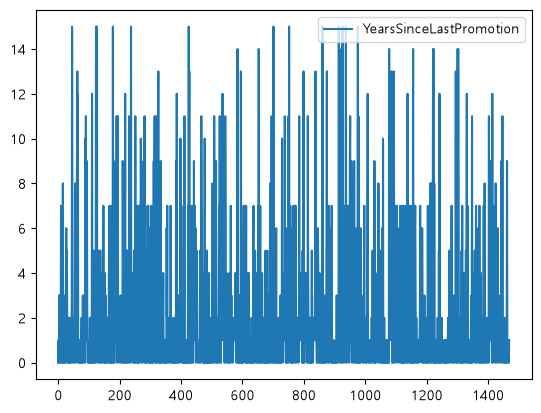

In [58]:
hr_df[["Attrition","YearsSinceLastPromotion"]]

<Axes: xlabel='YearsSinceLastPromotion', ylabel='Attrition'>

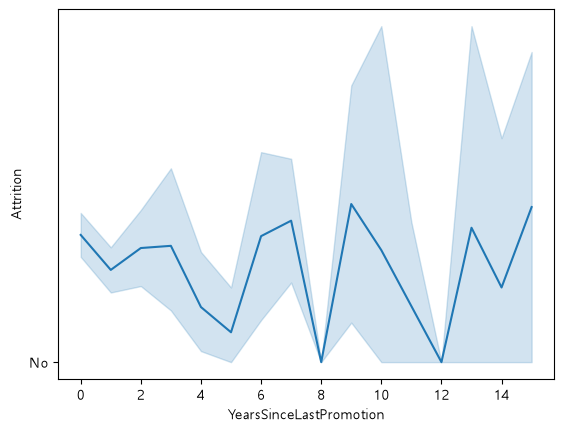

In [59]:
sns.lineplot(data=hr_df,x="YearsSinceLastPromotion",y="Attrition")

In [72]:
attrition_promo = pd.crosstab(hr_df["YearsSinceLastPromotion"], hr_df["Attrition"], normalize="index")
attrition_promo

Attrition,No,Yes
YearsSinceLastPromotion,,
0,0.810671,0.189329
1,0.862745,0.137255
2,0.830189,0.169811
3,0.826923,0.173077
4,0.918033,0.081967
5,0.955556,0.044444
6,0.812500,0.187500
7,0.789474,0.210526
8,1.000000,0.000000


<Axes: xlabel='YearsSinceLastPromotion'>

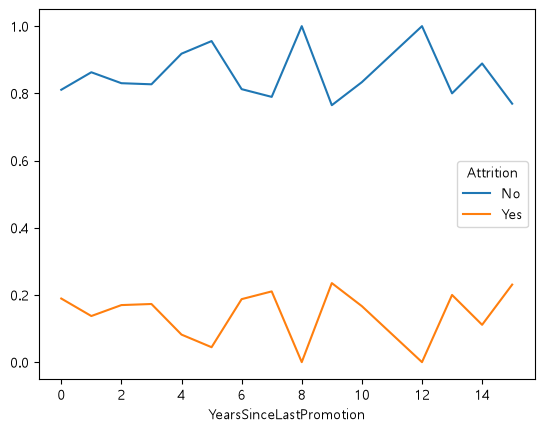

In [73]:
attrition_promo.plot(kind="line")

#### 워라밸 만족도(WorkLifeBalance) 1~4점 점수별 이직률 구하고, 워라밸 1점의 이직 위험도를 분석하기

In [112]:
wlb_attrition = pd.crosstab(hr_df["WorkLifeBalance"], hr_df["Attrition"], normalize="index")
wlb_attrition

Attrition,No,Yes
WorkLifeBalance,,
1,0.687500,0.312500
2,0.831395,0.168605
3,0.857783,0.142217
4,0.823529,0.176471


In [113]:
pd.DataFrame(data=wlb_attrition,index=[1])

Attrition,No,Yes
1,0.6875,0.3125


In [107]:
wlb_attrition["Yes"]

WorkLifeBalance
1    0.312500
2    0.168605
3    0.142217
4    0.176471
Name: Yes, dtype: float64

In [91]:
hr_df.groupby("WorkLifeBalance")["Attrition"].count()

WorkLifeBalance
1     80
2    344
3    893
4    153
Name: Attrition, dtype: int64

<Axes: xlabel='WorkLifeBalance'>

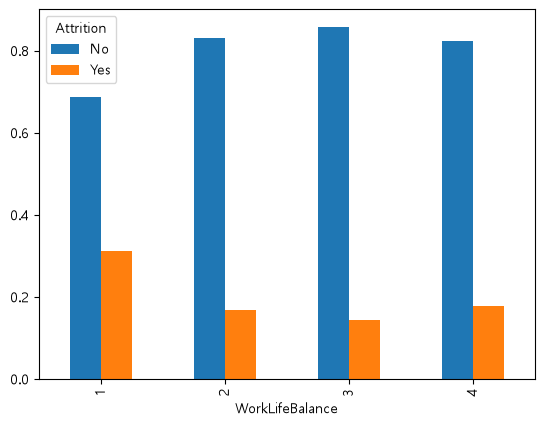

In [82]:
wlb_attrition.plot(kind="bar")

(0.0, 0.5)

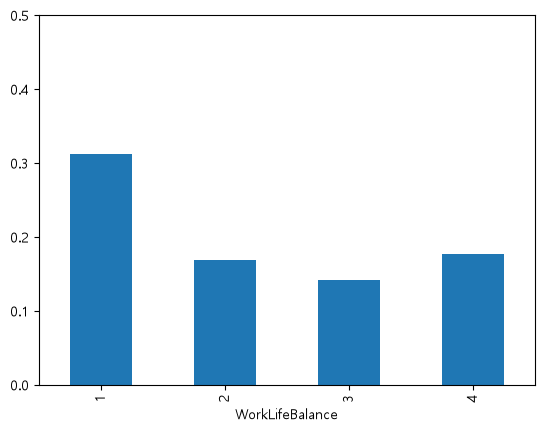

In [110]:
wlb_attrition["Yes"].plot(kind="bar")
plt.ylim(0,0.5)

#### 야근(OverTime)을 하는 직원과 야근을 하지 않는 직원의 이직률 차이가 얼마나 나는지 비교하고 결과를 서술하세요.

In [136]:
overtime_attrition = hr_df.groupby("OverTime")["Attrition"].agg(attrition = lambda x: (x=="Yes").mean()) 

<Axes: xlabel='OverTime'>

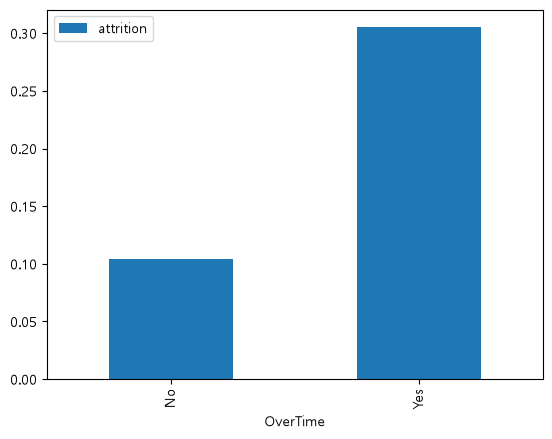

In [137]:
overtime_attrition.plot(kind="bar")

#### 이직한 직원(Attrition = Yes)과 잔류한 직원(No)의 월소득(MonthlyIncome) 평균 및 분포 차이 비교

<Axes: xlabel='Attrition'>

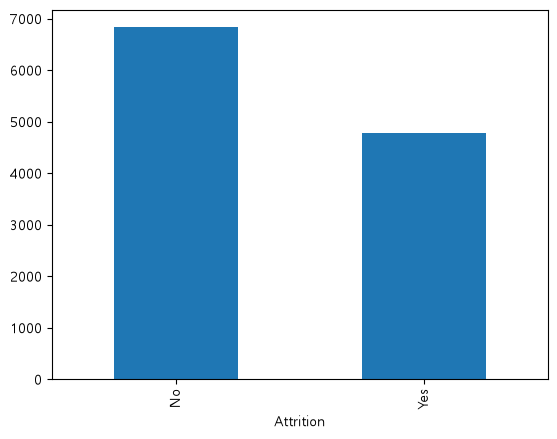

In [140]:
income_mean = hr_df.groupby("Attrition")["MonthlyIncome"].mean()
income_mean.plot(kind="bar")

np.float64(2373.0)

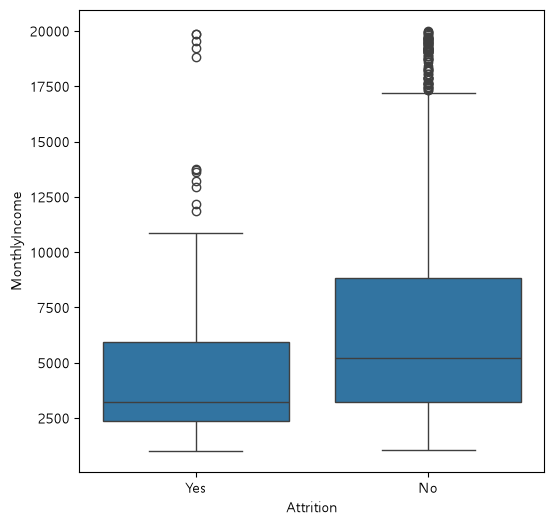

In [32]:
plt.figure(figsize=(6,6))
ax = sns.boxplot(data=hr_df, x="Attrition", y="MonthlyIncome")

hr_df[hr_df["Attrition"]=="Yes"]["MonthlyIncome"].quantile(0.25)

In [36]:
Q1 = hr_df[hr_df["Attrition"]=="Yes"]["MonthlyIncome"].quantile(0.25)
Q3 = hr_df[hr_df["Attrition"]=="Yes"]["MonthlyIncome"].quantile(0.75)

Q3 + (Q3 - Q1) * 1.5  # 최대 이상치
Q1 - (Q3 - Q1) * 1.5  # 최소 이상

np.float64(-2941.5)

#### 가설: 마지막 승진 후 기간(YearsSinceLastPromotion)이 길어질수록 이직률이 더 높아질까?

In [146]:
promo_attrition = hr_df.groupby("YearsSinceLastPromotion")["Attrition"].apply(lambda x: (x=="Yes").mean())

In [150]:
hr_df.groupby("YearsSinceLastPromotion")["Attrition"].count()

YearsSinceLastPromotion
0     581
1     357
2     159
3      52
4      61
5      45
6      32
7      76
8      18
9      17
10      6
11     24
12     10
13     10
14      9
15     13
Name: Attrition, dtype: int64

(0.0, 0.5)

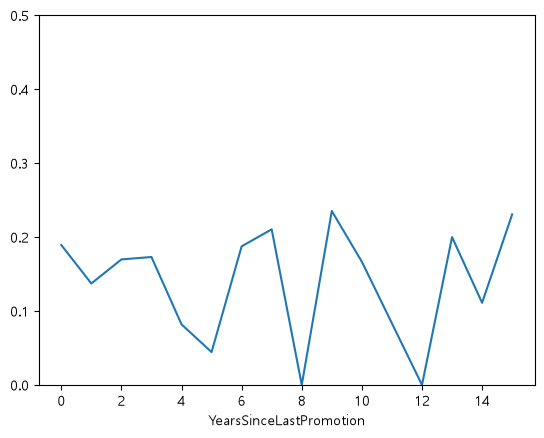

In [148]:
promo_attrition.plot(kind='line')
plt.ylim(0,0.5)

#### 워라밸 만족도(WorkLifeBalance) 1~4점 점수별 이직률 구하고, 워라밸 1점의 이직 위험도를 분석하기

In [153]:
wlb_attrition = hr_df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100)

(0.0, 50.0)

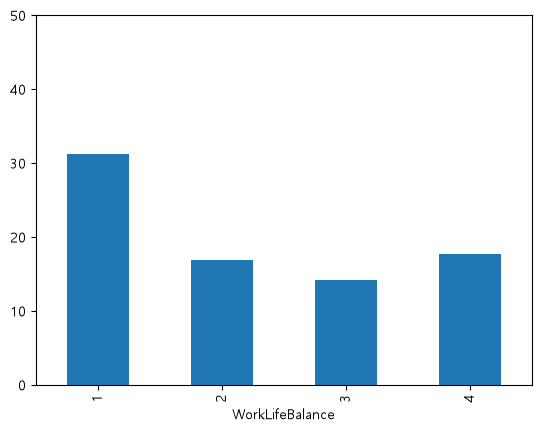

In [157]:
wlb_attrition.plot(kind="bar")
plt.ylim(0,50)

In [26]:
test_df = pd.DataFrame(
    np.random.randn(10, 4),
    columns=["월", "화", "수", "목"],
    index=np.arange(0, 100, 10)
)

test_df["월"]

0    -1.370621
10    0.248642
20   -0.658578
30   -0.509598
40   -1.790696
50   -0.826833
60    0.112673
70    0.571201
80    0.421421
90   -0.339279
Name: 월, dtype: float64

In [29]:
test_df["월"].to_frame()

,월
0,-1.370621
10,0.248642
20,-0.658578
30,-0.509598
40,-1.790696
50,-0.826833
60,0.112673
70,0.571201
80,0.421421
90,-0.339279


Text(0.5, 0, 'x축')

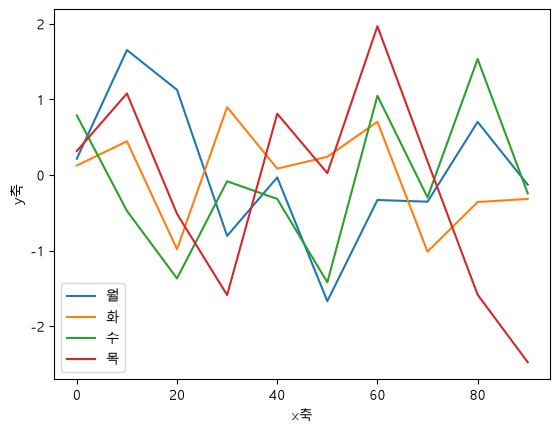

In [15]:
test_df.plot()
plt.ylabel("y축")
# y축 제목
plt.xlabel("x축")
# x축 제목

In [19]:
y = np.random.randint(20, size=10)
x = [chr(i) for i in range(97,107)]
s1 = pd.Series(data=y, index=x)

<Axes: >

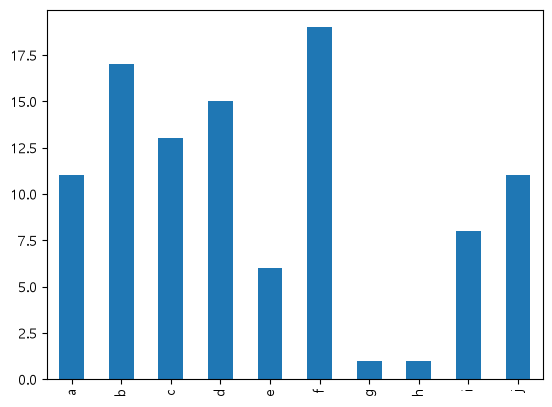

In [20]:
s1.plot(kind="bar")

In [2]:

df = pd.DataFrame({
    "product": ["A", "B", "C", "D", "E", "F", "F"],
    "price": [12000, 15000, np.nan, 18000, 20000, 999999, 999999],
    "stock": [10, 5, 8, np.nan, 20, 3, 3],
    "category": ["식품", "전자", "식품", "전자", np.nan, "식품", "식품"],
    "sold": [5, 2, 7, 1, 9, 3, 3]
})

df

,product,price,stock,category,sold
0,A,12000.0,10.0,식품,5
1,B,15000.0,5.0,전자,2
2,C,NaN,8.0,식품,7
3,D,18000.0,NaN,전자,1
4,E,20000.0,20.0,NaN,9
5,F,999999.0,3.0,식품,3
6,F,999999.0,3.0,식품,3


#### 각 컬럼별 결측치 개수를 확인하시오.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   product   7 non-null      str    
 1   price     6 non-null      float64
 2   stock     6 non-null      float64
 3   category  6 non-null      str    
 4   sold      7 non-null      int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 412.0 bytes


In [4]:
# price의 결측치를 price의 중앙값으로 대체하시오.
df["price"] = df["price"].fillna(df["price"].dropna().median())
df

,product,price,stock,category,sold
0,A,12000.0,10.0,식품,5
1,B,15000.0,5.0,전자,2
2,C,19000.0,8.0,식품,7
3,D,18000.0,NaN,전자,1
4,E,20000.0,20.0,NaN,9
5,F,999999.0,3.0,식품,3
6,F,999999.0,3.0,식품,3


In [5]:
# stock의 결측치를 stock의 평균값으로 대체하시오.
df["stock"] = df["stock"].fillna(df["stock"].dropna().mean())

In [6]:
# category의 결측치를 category의 최빈값으로 대체하시오.
df["category"] = df["category"].fillna(df["category"].dropna().mode()[0])
df

,product,price,stock,category,sold
0,A,12000.0,10.000000,식품,5
1,B,15000.0,5.000000,전자,2
2,C,19000.0,8.000000,식품,7
3,D,18000.0,8.166667,전자,1
4,E,20000.0,20.000000,식품,9
5,F,999999.0,3.000000,식품,3
6,F,999999.0,3.000000,식품,3


In [7]:
# 중복된 행을 제거하시오.
df.drop_duplicates(inplace=True)
df

,product,price,stock,category,sold
0,A,12000.0,10.000000,식품,5
1,B,15000.0,5.000000,전자,2
2,C,19000.0,8.000000,식품,7
3,D,18000.0,8.166667,전자,1
4,E,20000.0,20.000000,식품,9
5,F,999999.0,3.000000,식품,3


In [8]:
# 인덱스를 0부터 다시 설정하시오.
df.reset_index()

,index,product,price,stock,category,sold
0,0,A,12000.0,10.000000,식품,5
1,1,B,15000.0,5.000000,전자,2
2,2,C,19000.0,8.000000,식품,7
3,3,D,18000.0,8.166667,전자,1
4,4,E,20000.0,20.000000,식품,9
5,5,F,999999.0,3.000000,식품,3


In [9]:
# price * sold 값을 계산하여 revenue 컬럼을 생성하시오.
df["revenue"] = df["price"] * df["sold"]
df

,product,price,stock,category,sold,revenue
0,A,12000.0,10.000000,식품,5,60000.0
1,B,15000.0,5.000000,전자,2,30000.0
2,C,19000.0,8.000000,식품,7,133000.0
3,D,18000.0,8.166667,전자,1,18000.0
4,E,20000.0,20.000000,식품,9,180000.0
5,F,999999.0,3.000000,식품,3,2999997.0


In [ ]:
# revenue가 100000 이상인 데이터만 high_revenue에 저장하시오.
revenue_mask = df["revenue"] >= 100000

high_revenue = df[revenue_mask]
high_revenue

In [11]:
# high_revenue를 revenue가 높은 순서대로 정렬하시오.
high_revenue.sort_values(by="revenue",ascending=False)

,product,price,stock,category,sold,revenue
5,F,999999.0,3.0,식품,3,2999997.0
4,E,20000.0,20.0,식품,9,180000.0
2,C,19000.0,8.0,식품,7,133000.0


In [92]:
# product, category, revenue 컬럼만 출력하시오.
high_revenue[["product","category","revenue"]]

,product,category,revenue
2,C,식품,133000.0
4,E,식품,180000.0
5,F,식품,2999997.0


In [93]:
# category별 평균 price를 구하시오.
df.groupby("category")["price"].mean()

category
식품    262749.75
전자     16500.00
Name: price, dtype: float64

In [94]:
# category별 sold의 합계를 구하시오.
df.groupby("category")["sold"].sum()

category
식품    24
전자     3
Name: sold, dtype: int64

In [99]:
# category별 상품 개수를 구하시오.
df.groupby("category")["category"].count()

category
식품    4
전자    2
Name: category, dtype: int64

In [100]:
# category별 price의 count, mean, min, max를 한 번에 출력하시오.
df.groupby("category")["price"].agg(["count","mean","min","max"])

,count,mean,min,max
category,,,,
식품,4,262749.75,12000.0,999999.0
전자,2,16500.00,15000.0,18000.0


(array([5., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([ 12000. , 110799.9, 209599.8, 308399.7, 407199.6, 505999.5,
        604799.4, 703599.3, 802399.2, 901199.1, 999999. ]),
 <BarContainer object of 10 artists>)

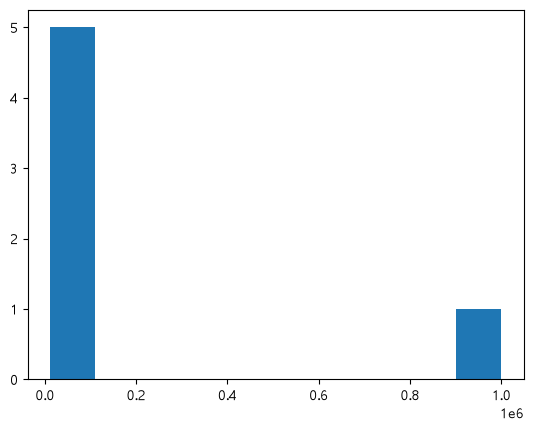

In [101]:
# price의 분포를 histplot으로 시각화하시오.
plt.hist(df["price"])

<Axes: xlabel='category'>

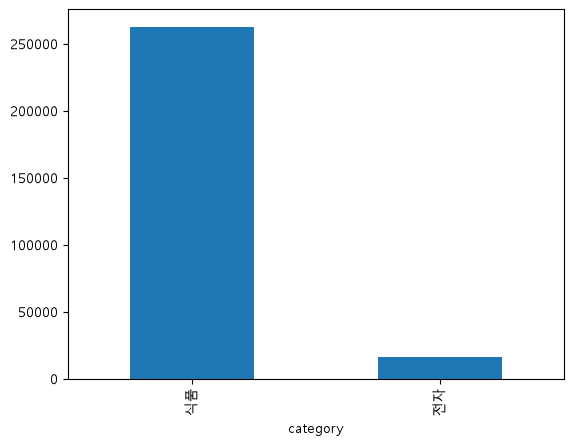

In [105]:
# category별 평균 price를 barplot으로 시각화하시오.
df.groupby("category")["price"].mean().plot(kind="bar")

<Axes: xlabel='category', ylabel='price'>

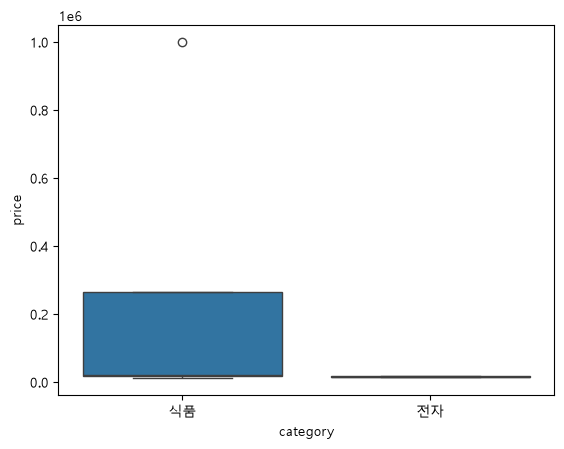

In [106]:
# category별 price 분포를 boxplot으로 시각화하시오.
sns.boxplot(data=df, x="category",y="price")

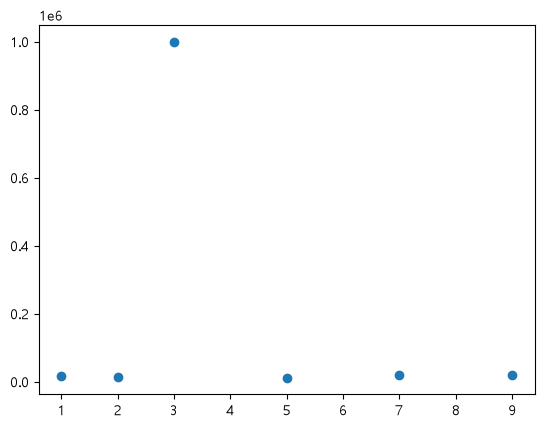

In [114]:
# price와 sold의 관계를 scatterplot으로 시각화하시오.
plt.scatter(df["sold"],df["price"])

In [12]:
# Q1을 구하시오.
# Q3를 구하시오.
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

In [14]:
# IQR을 구하시오.
IQR = Q3 - Q1

In [15]:
# lower, upper를 계산하시오.
lower = Q1 - IQR * 1.5
upper = Q3 + IQR * 1.5

In [25]:
# 정상 범위의 데이터만 clean_df에 저장하시오.
IQR_mask = (lower <= df["price"]) & (upper >= df["price"])
clean_df = df[IQR_mask]
clean_df

,product,price,stock,category,sold,revenue
0,A,12000.0,10.000000,식품,5,60000.0
1,B,15000.0,5.000000,전자,2,30000.0
2,C,19000.0,8.000000,식품,7,133000.0
3,D,18000.0,8.166667,전자,1,18000.0
4,E,20000.0,20.000000,식품,9,180000.0


<Axes: ylabel='price'>

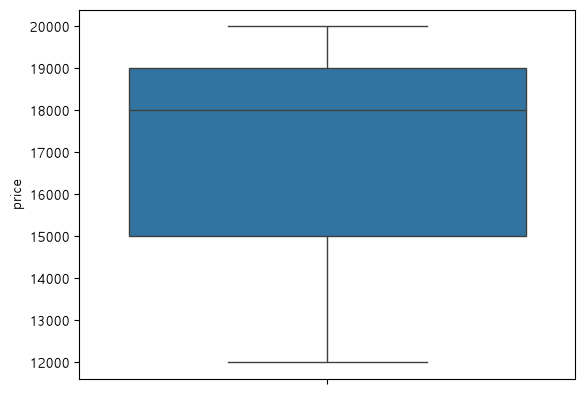

In [26]:
# 이상치 제거 후 clean_df의 price를 boxplot으로 시각화하시오.
sns.boxplot(data=clean_df["price"])

In [2]:
close_df = pd.DataFrame({
    "TSLA": [250, 255, 248, 260, 270],
    "MSFT": [400, 405, 410, 408, 415],
    "KO": [60, 60.5, 60.2, 61, 61.3]
})
close_df

,TSLA,MSFT,KO
0,250,400,60.0
1,255,405,60.5
2,248,410,60.2
3,260,408,61.0
4,270,415,61.3


In [3]:
# 전일 대비 일별 수익률을 계산하여 returns_df에 저장하시오.
returns_df = close_df.pct_change()
returns_df

,TSLA,MSFT,KO
0,NaN,NaN,NaN
1,0.020000,0.012500,0.008333
2,-0.027451,0.012346,-0.004959
3,0.048387,-0.004878,0.013289
4,0.038462,0.017157,0.004918


In [4]:
# 수익률 계산으로 발생한 결측치를 제거하시오.
returns_df.dropna(inplace=True)

In [62]:
# 각 종목의 평균 수익률을 구하시오.
returns_df.mean().to_frame(name="수익률 산술평균")

,수익률 산술평균
TSLA,0.019849
MSFT,0.009281
KO,0.005395


In [92]:
# 각 종목의 수익률 표준편차를 구하시오.
returns_df.std()

TSLA    0.033656
MSFT    0.009700
KO      0.007711
dtype: float64

In [93]:
returns_df.std(axis=1)

1    0.005912
2    0.019955
3    0.027077
4    0.016975
dtype: float64

In [79]:
returns_df - returns_df.mean()

,TSLA,MSFT,KO
1,0.000151,0.003219,0.002938
2,-0.047300,0.003065,-0.010354
3,0.028538,-0.014159,0.007894
4,0.018612,0.007876,-0.000477


In [6]:
# 종목 간 상관계수를 확인하시오.
close_df.corr(numeric_only=True)

,TSLA,MSFT,KO
TSLA,1.000000,0.679877,0.954971
MSFT,0.679877,1.000000,0.756911
KO,0.954971,0.756911,1.000000


<Axes: >

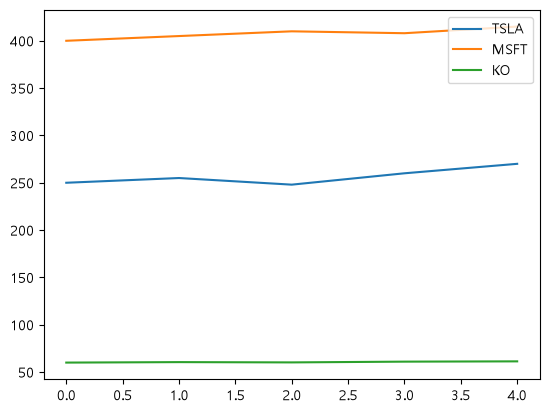

In [7]:
# close_df의 종가 변화를 선그래프로 시각화하시오.
close_df.plot(kind="line")

<Axes: >

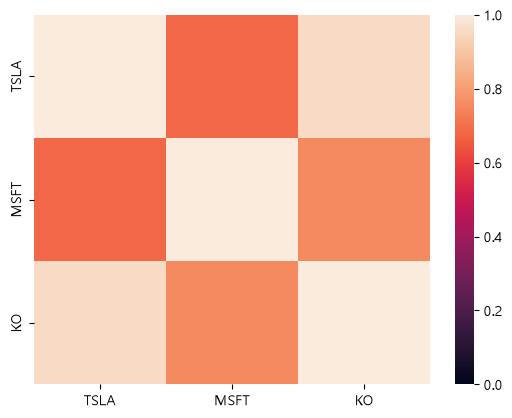

In [12]:
sns.heatmap(data=close_df.corr(numeric_only=True),vmin=0)